<a href="https://colab.research.google.com/github/sofiacicutti/data_science/blob/main/Avaliacaocienciadedados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratório de Ciência de Dados aplicado ao Marketing Digital

## Análise de Dados de Campanhas e Tomada de Decisão

Disciplina:Ciência de Dados e Marketing Digital
Tema: Análise de desempenho de campanhas digitais

### Integrantes
- Nome 1: Nicole Sarnáglia
- Nome 2: Sofia Cicutti
- Nome 3: Rafaela Toshiaki
- Nome 4: Fernanda Sayuri
- Nome 5: Mayza Bispo

## 1. Contextualização

A empresa analisada investiu em quatro canais de Marketing Digital: Google Ads,
Meta Ads, Instagram e LinkedIn Ads.

Os dados disponíveis apresentam informações sobre investimento, impressões,
alcance, cliques, interações, leads, conversões e receita.

### Perguntas de negócio

1. Quais canais apresentam maior volume de conversões?
2. Quais canais apresentam melhor eficiência considerando CPA e ROAS?

### Decisões que podem ser investigadas

- Identificar quais canais devem ser analisados para possível manutenção ou
ampliação de investimento.
- Identificar quais canais precisam ser revisados ou testados para melhorar
sua eficiência.

### Hipótese inicial

Inicialmente, levantamos a hipótese de que os canais com maior investimento
podem apresentar maior volume de conversões. Entretanto, essa relação precisa
ser verificada pelos dados e não deve ser tratada como causalidade sem testes
adicionais.

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving campanhas_marketing_digital.csv to campanhas_marketing_digital (2).csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

# Fazer upload do arquivo
uploaded = files.upload()

# Identificar o nome do arquivo enviado
nome_arquivo = list(uploaded.keys())[0]

# Ler o arquivo (usando a variável que contém o nome do arquivo)
# Se for um arquivo de texto separado por tabulação, podemos usar sep='\t'
try:
    df = pd.read_csv(nome_arquivo, sep='\t')
except Exception:
    df = pd.read_csv(nome_arquivo)

# Exibir as primeiras linhas
df.head()

### Solução 1: Lendo o arquivo atual (UTF-16)
O arquivo que você enviou (`dados canais (1).txt`) está codificado em UTF-16. O código abaixo corrige o erro de leitura identificando a codificação correta e o caractere separador (vírgula ou tabulação).

In [ ]:
import pandas as pd

try:
    # Tenta ler com a codificação padrão UTF-8
    df = pd.read_csv(nome_arquivo, sep=None, engine='python')
except UnicodeDecodeError:
    # Se falhar, tenta ler especificando a codificação UTF-16 (comum em exportações do Excel)
    df = pd.read_csv(nome_arquivo, sep=None, encoding='utf-16', engine='python')

# Exibe as primeiras linhas do DataFrame carregado
display(df.head())

,﻿data,canal,campanha,etapa_funil,investimento,impressoes,alcance,cliques,interacoes,leads,conversoes,receita
0,2026-08-03,Google Ads,Pesquisa Marca,Fundo de funil,1200,52000,41000,2600,310,150.0,58,8700
1,2026-08-03,Meta Ads,Conversao Social,Meio de funil,1000,78000,59000,2340,410,118.0,42,5200
2,2026-08-03,Instagram,Conteudo Impulsionado,Topo de funil,650,92000,68000,1840,520,72.0,18,1800
3,2026-08-03,LinkedIn Ads,Leads B2B,Meio de funil,900,31000,24500,930,145,64.0,16,4800
4,2026-08-10,Google Ads,Pesquisa Marca,Fundo de funil,1250,54000,42500,2862,335,162.0,63,9450


In [ ]:
# Agrupando os dados por canal de marketing
analise_canais = df.groupby('canal').agg({
    'investimento': 'sum',
    'cliques': 'sum',
    'conversoes': 'sum',
    'receita': 'sum'
}).reset_index()

# Calculando as metricas de eficiencia
analise_canais['CPA'] = analise_canais['investimento'] / analise_canais['conversoes']
analise_canais['ROAS'] = analise_canais['receita'] / analise_canais['investimento']
analise_canais['Taxa de Conversao (%)'] = (analise_canais['conversoes'] / analise_canais['cliques']) * 100

# Ordenando pelo maior volume de conversoes
analise_canais = analise_canais.sort_values(by='conversoes', ascending=False)

pd.options.display.float_format = '{:.2f}'.format
display(analise_canais)

,canal,investimento,cliques,conversoes,receita,CPA,ROAS,Taxa de Conversao (%)
0,Google Ads,8250,18902,416,62400,19.83,7.56,2.20
4,Meta Ads,7100,15451,296,36950,23.99,5.20,1.92
3,LinkedIn Ads,6500,6113,111,33300,58.56,5.12,1.82
1,Instagram,4130,10138,108,10800,38.24,2.62,1.07
2,Instagram,700,2016,20,2000,35.00,2.86,0.99


In [ ]:
# Agrupando os dados por canal de marketing
analise_canais = df.groupby('canal').agg({
    'investimento': 'sum',
    'cliques': 'sum',
    'conversoes': 'sum',
    'receita': 'sum'
}).reset_index()

# Calculando métricas de eficiência
analise_canais['CPA (Custo por Aquisição)'] = analise_canais['investimento'] / analise_canais['conversoes']
analise_canais['ROAS'] = analise_canais['receita'] / analise_canais['investimento']
analise_canais['Taxa de Conversão (%)'] = (analise_canais['conversoes'] / analise_canais['cliques']) * 100

# Ordenando pelo maior volume de conversões
analise_canais = analise_canais.sort_values(by='conversoes', ascending=False)

# Exibindo o resultado formatado
pd.options.display.float_format = '{:.2f}'.format
print("Desempenho Geral por Canal de Marketing:")
display(analise_canais)

Desempenho Geral por Canal de Marketing:


,canal,investimento,cliques,conversoes,receita,CPA (Custo por Aquisição),ROAS,Taxa de Conversão (%)
0,Google Ads,8250,18902,416,62400,19.83,7.56,2.20
4,Meta Ads,7100,15451,296,36950,23.99,5.20,1.92
3,LinkedIn Ads,6500,6113,111,33300,58.56,5.12,1.82
1,Instagram,4130,10138,108,10800,38.24,2.62,1.07
2,Instagram,700,2016,20,2000,35.00,2.86,0.99


In [ ]:
# Quantidade de linhas e colunas
print("Dimensões da base:", df.shape)

# Informações gerais
df.info()

# Estatísticas descritivas
display(df.describe())

# Verificar valores ausentes
print("\nValores ausentes:")
display(df.isna().sum())

# Verificar duplicados
print("\nQuantidade de linhas duplicadas:", df.duplicated().sum())

# Verificar categorias de canal
print("\nCategorias de canal:")
print(df["canal"].unique())

Dimensões da base: (24, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ﻿data         24 non-null     object 
 1   canal         24 non-null     object 
 2   campanha      24 non-null     object 
 3   etapa_funil   24 non-null     object 
 4   investimento  24 non-null     int64  
 5   impressoes    24 non-null     int64  
 6   alcance       24 non-null     int64  
 7   cliques       24 non-null     int64  
 8   interacoes    24 non-null     int64  
 9   leads         23 non-null     float64
 10  conversoes    24 non-null     int64  
 11  receita       24 non-null     int64  
dtypes: float64(1), int64(7), object(4)
memory usage: 2.4+ KB


,investimento,impressoes,alcance,cliques,interacoes,leads,conversoes,receita
count,24.00,24.00,24.00,24.00,24.00,23.00,24.00,24.00
mean,1111.67,70770.83,53175.00,2192.50,395.50,118.65,39.62,6060.42
std,255.86,27347.99,19118.29,827.10,162.64,45.13,21.91,3081.87
min,650.00,31000.00,24500.00,930.00,145.00,64.00,16.00,1800.00
25%,937.50,49000.00,38500.00,1650.00,278.50,79.00,20.00,4200.00
50%,1100.00,71500.00,54500.00,2220.00,415.00,118.00,33.00,5875.00
75%,1300.00,93000.00,69350.00,2673.00,512.50,150.50,55.75,7331.25
max,1600.00,116000.00,83000.00,3640.00,660.00,205.00,80.00,12000.00



Valores ausentes:


,0
﻿data,0
canal,0
campanha,0
etapa_funil,0
investimento,0
impressoes,0
alcance,0
cliques,0
interacoes,0
leads,1



Quantidade de linhas duplicadas: 0

Categorias de canal:
['Google Ads' 'Meta Ads' 'Instagram' 'LinkedIn Ads' 'Instagram ']


## 2. Diagnóstico e tratamento dos dados

A base possui 24 registros e 12 variáveis.

Foi identificado um problema de consistência na variável `canal`, com a
presença de um espaço extra em uma categoria de Instagram.

Também foi identificado um valor ausente na variável `leads`.

O valor ausente não será substituído automaticamente por zero, pois não é
possível afirmar que a ausência significa que nenhum lead foi gerado.
O valor será mantido como ausente (`NaN`) e considerado uma limitação da análise.

Não foram identificadas linhas duplicadas.

In [ ]:
# Criar uma cópia para tratamento
df_tratado = df.copy()

# Remover o caractere BOM (\ufeff) e espaços extras dos nomes das colunas
df_tratado.columns = df_tratado.columns.str.replace('\ufeff', '').str.strip()

# Remover espaços extras da variável canal
df_tratado["canal"] = df_tratado["canal"].str.strip()

# Converter a variável data para datetime
df_tratado["data"] = pd.to_datetime(df_tratado["data"])

# Conferir os canais após o tratamento
print("Canais após tratamento:")
print(df_tratado["canal"].unique())

# Conferir os valores ausentes
print("\nValores ausentes:")
display(df_tratado.isna().sum())

Canais após tratamento:
['Google Ads' 'Meta Ads' 'Instagram' 'LinkedIn Ads']

Valores ausentes:


,0
data,0
canal,0
campanha,0
etapa_funil,0
investimento,0
impressoes,0
alcance,0
cliques,0
interacoes,0
leads,1


In [ ]:
# CTR
df_tratado["CTR"] = (
    df_tratado["cliques"] / df_tratado["impressoes"]
) * 100

# Taxa de conversão
df_tratado["taxa_conversao"] = (
    df_tratado["conversoes"] / df_tratado["cliques"]
) * 100

# CPC
df_tratado["CPC"] = (
    df_tratado["investimento"] / df_tratado["cliques"]
)

# CPA
df_tratado["CPA"] = (
    df_tratado["investimento"] / df_tratado["conversoes"]
)

# ROAS
df_tratado["ROAS"] = (
    df_tratado["receita"] / df_tratado["investimento"]
)

# Mostrar as métricas
display(
    df_tratado[
        [
            "data",
            "canal",
            "investimento",
            "cliques",
            "conversoes",
            "receita",
            "CTR",
            "taxa_conversao",
            "CPC",
            "CPA",
            "ROAS"
        ]
    ].round(2)
)

,data,canal,investimento,cliques,conversoes,receita,CTR,taxa_conversao,CPC,CPA,ROAS
0,2026-08-03,Google Ads,1200,2600,58,8700,5.00,2.23,0.46,20.69,7.25
1,2026-08-03,Meta Ads,1000,2340,42,5200,3.00,1.79,0.43,23.81,5.20
2,2026-08-03,Instagram,650,1840,18,1800,2.00,0.98,0.35,36.11,2.77
3,2026-08-03,LinkedIn Ads,900,930,16,4800,3.00,1.72,0.97,56.25,5.33
4,2026-08-10,Google Ads,1250,2862,63,9450,5.30,2.20,0.44,19.84,7.56
5,2026-08-10,Meta Ads,1050,2511,46,5750,3.10,1.83,0.42,22.83,5.48
6,2026-08-10,Instagram,700,2016,20,2000,2.10,0.99,0.35,35.00,2.86
7,2026-08-10,LinkedIn Ads,950,975,17,5100,3.00,1.74,0.97,55.88,5.37
8,2026-08-17,Google Ads,1300,3024,67,10050,5.40,2.22,0.43,19.40,7.73
9,2026-08-17,Meta Ads,1100,2604,49,6125,3.10,1.88,0.42,22.45,5.57


In [ ]:
# Agrupamento por canal
tabela_canais = df_tratado.groupby("canal").agg({
    "investimento": "sum",
    "impressoes": "sum",
    "alcance": "sum",
    "cliques": "sum",
    "interacoes": "sum",
    "leads": "sum",
    "conversoes": "sum",
    "receita": "sum"
}).reset_index()

# Recalcular métricas com os totais
tabela_canais["CTR"] = (
    tabela_canais["cliques"] /
    tabela_canais["impressoes"]
) * 100

tabela_canais["taxa_conversao"] = (
    tabela_canais["conversoes"] /
    tabela_canais["cliques"]
) * 100

tabela_canais["CPC"] = (
    tabela_canais["investimento"] /
    tabela_canais["cliques"]
)

tabela_canais["CPA"] = (
    tabela_canais["investimento"] /
    tabela_canais["conversoes"]
)

tabela_canais["ROAS"] = (
    tabela_canais["receita"] /
    tabela_canais["investimento"]
)

# Exibir tabela
display(tabela_canais.round(2))

,canal,investimento,impressoes,alcance,cliques,interacoes,leads,conversoes,receita,CTR,taxa_conversao,CPC,CPA,ROAS
0,Google Ads,8250,348000,271300,18902,2198,1067.00,416,62400,5.43,2.20,0.44,19.83,7.56
1,Instagram,4830,620000,449900,12154,3535,408.00,128,12800,1.96,1.05,0.40,37.73,2.65
2,LinkedIn Ads,6500,211500,164800,6113,984,444.00,111,33300,2.89,1.82,1.06,58.56,5.12
3,Meta Ads,7100,519000,390200,15451,2775,810.00,296,36950,2.98,1.92,0.46,23.99,5.20


In [ ]:
# Selecionar Google Ads de 03/08/2026
registro_google = df_tratado[
    (df_tratado["canal"] == "Google Ads") &
    (df_tratado["data"] == "2026-08-03")
]

display(
    registro_google[
        [
            "data",
            "canal",
            "investimento",
            "impressoes",
            "cliques",
            "conversoes",
            "receita",
            "CTR",
            "taxa_conversao",
            "CPC",
            "CPA",
            "ROAS"
        ]
    ].round(2)
)

,data,canal,investimento,impressoes,cliques,conversoes,receita,CTR,taxa_conversao,CPC,CPA,ROAS
0,2026-08-03,Google Ads,1200,52000,2600,58,8700,5.00,2.23,0.46,20.69,7.25


In [ ]:
print("Canal com maior volume de conversões:")
print(
    tabela_canais.loc[
        tabela_canais["conversoes"].idxmax(), "canal"
    ]
)

print("\nCanal com maior taxa de conversão:")
print(
    tabela_canais.loc[
        tabela_canais["taxa_conversao"].idxmax(), "canal"
    ]
)

print("\nCanal com maior ROAS:")
print(
    tabela_canais.loc[
        tabela_canais["ROAS"].idxmax(), "canal"
    ]
)

print("\nCanal com menor CPA:")
print(
    tabela_canais.loc[
        tabela_canais["CPA"].idxmin(), "canal"
    ]
)

Canal com maior volume de conversões:
Google Ads

Canal com maior taxa de conversão:
Google Ads

Canal com maior ROAS:
Google Ads

Canal com menor CPA:
Google Ads


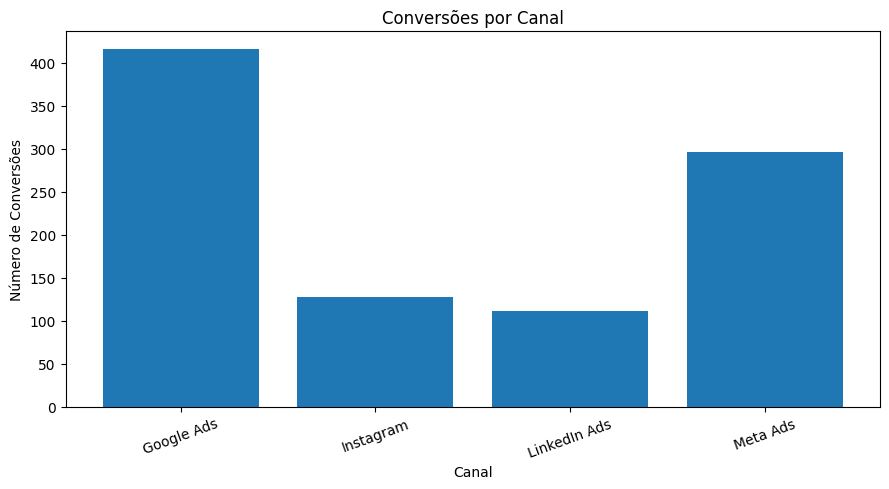

In [ ]:
plt.figure(figsize=(9, 5))

plt.bar(
    tabela_canais["canal"],
    tabela_canais["conversoes"]
)

plt.title("Conversões por Canal")
plt.xlabel("Canal")
plt.ylabel("Número de Conversões")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Interpretação do Gráfico 1

O Google Ads apresentou o maior volume de conversões, com 416 conversões,
seguido por Meta Ads, com 296. Instagram apresentou 128 conversões
e LinkedIn Ads apresentou 111.

Esse resultado é relevante porque permite visualizar a diferença de volume de
conversões entre os canais.

Entretanto, o volume de conversões sozinho não é suficiente para
avaliar eficiência. É necessário considerar também investimento, CPA,
taxa de conversão e ROAS.

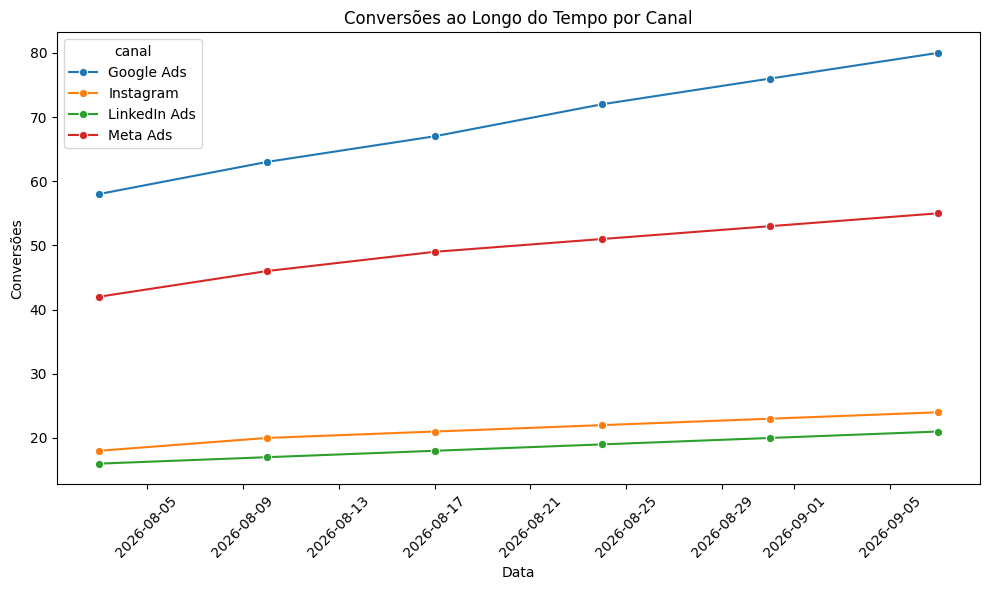

In [ ]:
# Agrupar conversões por data e canal
conversoes_tempo = (
    df_tratado
    .groupby(["data", "canal"])["conversoes"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=conversoes_tempo,
    x="data",
    y="conversoes",
    hue="canal",
    marker="o"
)

plt.title("Conversões ao Longo do Tempo por Canal")
plt.xlabel("Data")
plt.ylabel("Conversões")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Interpretação do Gráfico 2

As conversões apresentam crescimento ao longo do período analisado
nos quatro canais.

O Google Ads parte de 58 conversões em 03/08/2026 e chega a 80 conversões
em 07/09/2026. O Meta Ads passa de 42 para 55 conversões no mesmo período.
Instagram passa de 18 para 24, enquanto LinkedIn Ads passa de 16 para 21.

O padrão indica crescimento das conversões durante o período observado.
Entretanto, a base cobre um período limitado e não permite afirmar que
o crescimento foi causado exclusivamente pelo aumento do investimento.

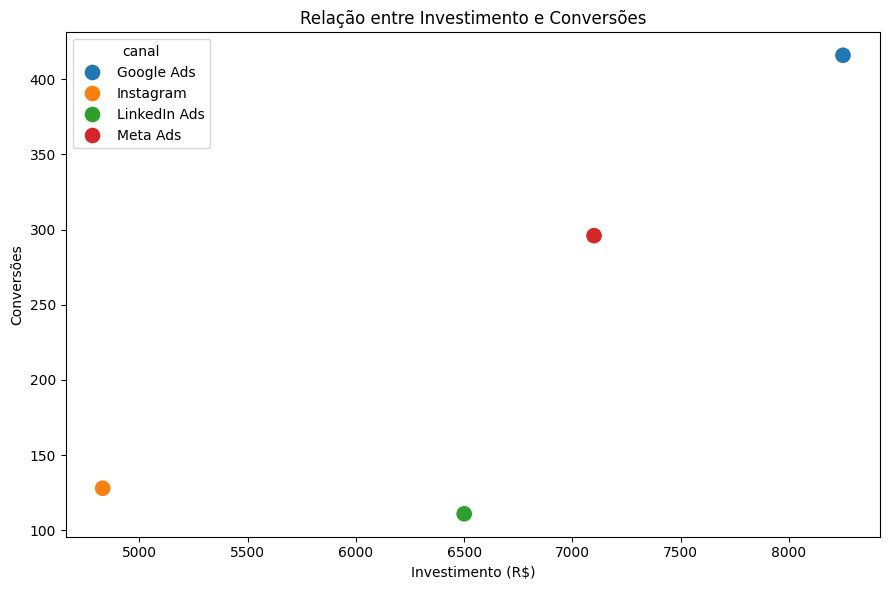

In [ ]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=tabela_canais,
    x="investimento",
    y="conversoes",
    hue="canal",
    s=150
)

plt.title("Relação entre Investimento e Conversões")
plt.xlabel("Investimento (R$)")
plt.ylabel("Conversões")

plt.tight_layout()
plt.show()

### Interpretação do Gráfico 3

O gráfico mostra uma associação positiva entre investimento e volume de
 conversões na base analisada. O Google Ads apresenta o maior investimento
 entre os canais e também o maior número de conversões.

Essa comparação é relevante para observar a relação entre recursos investidos
e resultados gerados.

Entretanto, associação não significa causalidade. Outros fatores podem
influenciar as conversões, como campanha, público, criativo, etapa do funil
e período analisado. Por isso, seria necessário realizar testes adicionais
antes de atribuir o aumento das conversões exclusivamente ao investimento.

In [ ]:
correlacao = df_tratado["investimento"].corr(
    df_tratado["conversoes"]
)

print(
    f"Correlação entre investimento e conversões: "
    f"{correlacao:.2f}"
)

### Interpretação da correlação

A correlação entre investimento e conversões foi aproximadamente 0,79, indicando
uma associação positiva entre as duas variáveis na base analisada.

Isso significa que, nos registros observados, maiores investimentos tendem a
aparecer associados a maiores volumes de conversões.

Entretanto, correlação não prova causalidade. O resultado não permite afirmar
que o aumento do investimento, isoladamente, causou o aumento das conversões.
Outros fatores podem influenciar os resultados.

# 3. Insights

### Insight 1 — Resultado positivo

O Google Ads apresentou o maior volume de conversões, com 416 conversões,
além da maior taxa de conversão, de 9,40%, e do maior ROAS, de 7,56.
Os dados indicam um desempenho relevante tanto em volume quanto nas métricas
de eficiência analisadas.

### Insight 2 — Resultado que merece atenção

O Instagram apresentou 128 conversões, taxa de conversão de 6,45%, CPA de
R$ 37,73 e ROAS de 2,65. Esses indicadores mostram que o canal deve ser
investigado considerando sua relação entre investimento e retorno.

### Insight 3 — Oportunidade

O Meta Ads apresentou 296 conversões, taxa de conversão de 8,15%, CPA de
R$ 23,99 e ROAS de 5,20. Esses resultados indicam que o canal possui volume
relevante de conversões e pode ser analisado em testes futuros de otimização
de campanha.

### Hipótese explicativa

Uma possível explicação para as diferenças de desempenho entre os canais é a
combinação de fatores como público, campanha, etapa do funil, criativo e
características do canal. Essa hipótese precisaria ser testada com dados
adicionais ou experimentos.

### Limitação

A análise não possui informações sobre margem, custos operacionais, impostos,
novos clientes, recorrência, LTV ou modelo de atribuição.
Portanto, o ROAS não deve ser interpretado como lucro.

# 4. Recomendações

### Recomendação 1

Realizar um teste controlado de otimização do investimento entre os canais,
utilizando como indicadores principais conversões, CPA e ROAS. O Google Ads
apresentou 416 conversões, CPA de R$ 19,83 e ROAS de 7,56, enquanto Instagram
apresentou 128 conversões, CPA de R$ 37,73 e ROAS de 2,65.
A redistribuição de orçamento não deve ser feita apenas com base nesses números;
recomenda-se primeiro testar a alteração e acompanhar os resultados.

### Recomendação 2

Investigar as campanhas do Instagram para identificar os fatores associados ao
CPA de R$ 37,73 e ao ROAS de 2,65. O teste pode envolver diferentes criativos,
públicos e mensagens, comparando os resultados com um grupo de referência.
O objetivo seria verificar se mudanças na estratégia conseguem melhorar as
métricas do canal.

# 4. Recomendações

### Recomendação 1

Realizar um teste controlado de otimização do investimento entre os canais,
utilizando como indicadores principais conversões, CPA e ROAS. O Google Ads
apresentou 416 conversões, CPA de R$ 19,83 e ROAS de 7,56, enquanto Instagram
apresentou 128 conversões, CPA de R$ 37,73 e ROAS de 2,65.
A redistribuição de orçamento não deve ser feita apenas com base nesses números;
recomenda-se primeiro testar a alteração e acompanhar os resultados.

### Recomendação 2

Investigar as campanhas do Instagram para identificar os fatores associados ao
CPA de R$ 37,73 e ao ROAS de 2,65. O teste pode envolver diferentes criativos,
públicos e mensagens, comparando os resultados com um grupo de referência.
O objetivo seria verificar se mudanças na estratégia conseguem melhorar as
métricas do canal.

# 6. Exercício 4 — Tendência e associação

### a) As conversões aumentam com o tempo em todos os canais?

Sim. Na base analisada, todos os quatro canais apresentam crescimento das
conversões ao longo das seis datas observadas.

### b) Correlação

A correlação entre investimento e conversões foi aproximadamente 0,79.

### c) Correlação não significa causalidade

A correlação indica que as variáveis apresentam associação na base observada,
mas não demonstra que uma variável causou a outra. Outros fatores podem
influenciar o resultado, sendo necessários testes ou dados adicionais para
investigar causalidade.

# 7. Exercício 5 — Comunicação de insight

### Insight 1

O Google Ads apresentou 416 conversões, representando o maior volume entre os
canais analisados. O canal também apresentou ROAS de 7,56 e CPA de R$ 19,83.

### Insight 2

O Meta Ads apresentou 296 conversões, taxa de conversão de 8,15%, CPA de
R$ 23,99 e ROAS de 5,20, mostrando volume relevante e indicadores de eficiência
que devem ser acompanhados.

### Insight 3

O Instagram apresentou 128 conversões, CPA de R$ 37,73 e ROAS de 2,65,
indicando a necessidade de investigar os fatores relacionados ao
desempenho do canal.

### Recomendação testável 1

Realizar um teste de redistribuição controlada do orçamento entre canais e
comparar conversões, CPA e ROAS antes e depois da alteração.

### Recomendação testável 2

Testar diferentes criativos, públicos e mensagens no Instagram e comparar os
resultados com campanhas de referência para verificar se as métricas de
eficiência podem ser melhoradas.

# 8. Conclusão

A análise das campanhas digitais mostrou diferenças importantes entre os canais
avaliados. O Google Ads apresentou 416 conversões, taxa de conversão de 9,40%,
CPA de R$ 19,83 e ROAS de 7,56. O Meta Ads apresentou 296 conversões e ROAS de
5,20, enquanto Instagram e LinkedIn Ads apresentaram volumes menores de
conversões. O Instagram merece investigação adicional devido ao CPA de R$ 37,73
e ROAS de 2,65. A correlação de aproximadamente 0,79 entre investimento e
conversões indica associação positiva na base, mas não permite afirmar
causalidade. Dessa forma, recomenda-se utilizar os resultados como ponto de
partida para testes controlados e análises adicionais. Entre as limitações estão
 a existência de um lead ausente e a ausência de informações sobre margem,
custos operacionais, novos clientes, recorrência, LTV e atribuição multicanal.

# 9. Limitações da análise

- A base possui um valor ausente na variável `leads`.
- A análise considera um período limitado.
- Não existem dados sobre margem de lucro.
- Não existem informações sobre custos operacionais.
- Não há dados sobre impostos.
- Não há informações sobre novos clientes e recorrência.
- Não há informação sobre LTV.
- Não há dados suficientes para avaliar atribuição multicanal.
- Correlação não permite estabelecer causalidade.
- O ROAS não representa lucro ou ROI.

# 10. Ticket de saída

**Antes de recomendar uma mudança de orçamento, eu verificaria os custos,
a margem, o comportamento das conversões, o CPA, o ROAS e dados adicionais sobre
clientes, porque essas informações ajudam a evitar decisões baseadas em apenas
uma métrica.**